In [23]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:
df = pd.read_csv("kc_house_data.csv")

In [3]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [8]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [9]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
21608    False
21609    False
21610    False
21611    False
21612    False
Length: 21613, dtype: bool

In [ ]:
x = df.drop('price', axis=1)
y = df["price"]

In [12]:
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    random_state=42,
    test_size= 0.2
)

In [15]:
model = LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
# Drop the date column
x_train = x_train.drop(columns=['date'])
x_test = x_test.drop(columns=['date'])

In [16]:
model.coef_

array([-1.33978221e-06, -3.43074736e+04,  4.45861014e+04,  1.08944477e+02,
        8.05637972e-02,  7.01981320e+03,  5.61992102e+05,  5.37898653e+04,
        2.43817431e+04,  9.47120482e+04,  6.99457982e+01,  3.89986788e+01,
       -2.68205192e+03,  2.02428706e+01, -5.51831873e+02,  5.95402284e+05,
       -1.92574700e+05,  2.11354355e+01, -3.39559834e-01])

In [17]:
model.intercept_

np.float64(6883865.792572488)

In [18]:
predct = model.predict(x_test)

In [19]:
print(predct)

[ 464059.0612097   747620.70054634 1234932.59986334 ...  427129.65837551
  618498.09042697  446067.84491722]


In [20]:
print(y_test)

735       365000.0
2830      865000.0
4106     1038000.0
16218    1490000.0
19964     711000.0
           ...    
13674     338000.0
20377     673000.0
8805      285000.0
10168     605000.0
2522      356500.0
Name: price, Length: 4323, dtype: float64


In [21]:
print("Actuasl Value:")
print(y_test)
print("\npredicted value")
print(predct)

Actuasl Value:
735       365000.0
2830      865000.0
4106     1038000.0
16218    1490000.0
19964     711000.0
           ...    
13674     338000.0
20377     673000.0
8805      285000.0
10168     605000.0
2522      356500.0
Name: price, Length: 4323, dtype: float64

predicted value
[ 464059.0612097   747620.70054634 1234932.59986334 ...  427129.65837551
  618498.09042697  446067.84491722]


In [22]:
mae = mean_absolute_error(y_test,predct)
mse = mean_squared_error(y_test,predct)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,predct)
print("MAE",mae)
print("MSE",mse)
print("RMSE",rmse)
print("r2",r2)

MAE 127474.10296303504
MSE 45164817780.89797
RMSE 212520.1585283099
r2 0.7012448735876677


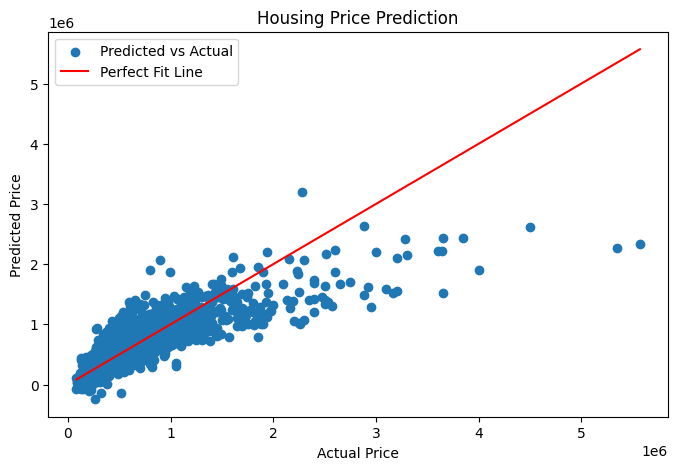

In [30]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, predct, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', label='Perfect Fit Line')
plt.title("Housing Price Prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.show()